# Fraud Detection System Report
#### Nainika Devireddy

## 1. System Design

### How the System Design Meets the Requirements
The Fraud Detection System is meticulously designed to address the outlined requirements, ensuring accurate, real-time fraud detection, prompt alert generation, and seamless integration with existing infrastructure.

#### Real-time Fraud Detection
The system analyzes transaction data as it occurs, leveraging pre-trained machine learning models to process large volumes of data with minimal latency. This ensures that fraudulent transactions are detected promptly, allowing for immediate action. The machine learning models are trained and evaluated when the dataset is generated to save time during inference data prediction. 

#### Alert Generation
Each prediction is logged along with the input data in a folder called predictions. Flagged transactions are transactions that have been classified as fraudulent by the machine learning model. Prediction data can be easily pushed to the Fraud Detection Department for further evaluation.

#### Model Performance
The system aims to achieve a precision of at least 40% and a recall of at least 85%, ensuring that a significant portion of fraudulent transactions are identified while minimizing false positives. Regular validation and fine-tuning help maintain and improve these metrics. The model trained on 'datasetA' boasts a precision of 99.39% and a recall of 100% when evaluated on a test dataset.

#### Documentation and Transparency
Comprehensive documentation of the algorithmic and decision-making processes ensures transparency and accountability. Logging mechanisms record all actions, making them traceable and auditable. The raw data descriptions, processed data and processed data descriptions, trained model, model evaluations

#### Integration with Existing Infrastructure
The system can be integrated seamlessly with SecureBank's existing databases and IT infrastructure. APIs facilitate access to user and transaction information and return fraudulent charge information with much ease. API calls can be easily automatically generated based on the transaction data to seemlessly retrieve predictions.

#### Facilitating Review Process
The system supports the entire fraud investigation process, from flagging transactions to final resolution. It allows for canceling or approving transactions, blocking or unblocking bank cards, and updating system performance metrics. With a high precision and recall score of the detection system, it is hoped that the department's workload cna be reduced. 

#### Scalability
The system is designed to handle numerous transactions from SecureBank's hundreds of thousands of clients. Cloud-based infrastructure can ensure scalability and efficiency. The use of APIs allow for seamless cloud integration.

#### Compliance and Ethical Operation
The system facilitates efficient and ethical practices. Documentation of the data used, predictions made, and the models trianed allows for regular audits and bias checks to take place easily to help comply with regulatory requirements and internal policies. 

### System Components and Processes
The following diagram illustrates the system components and processes:

1. **Data Ingestion**: (pink) Collects transaction data from various sources.
2. **Data Processing**: (pink) Cleans and preprocesses the data, including handling missing values, standardizing formats, and feature engineering.
3. **Data Sampling**: (pink) Samples the data to create a dataset for model training.
4. **Model Training**: (pink) Trains machine learning models using processed data.
5. **Model Evaluation**: (blue) Evaluates the trained model using various metrics to ensure accuracy and robustness.
6. **Prediction**: (purple) Provides an interface for making predictions on new transactions.
7. **Logging and Monitoring**: (blue) Logs system activities and monitors performance to ensure smooth operation and quick troubleshooting.

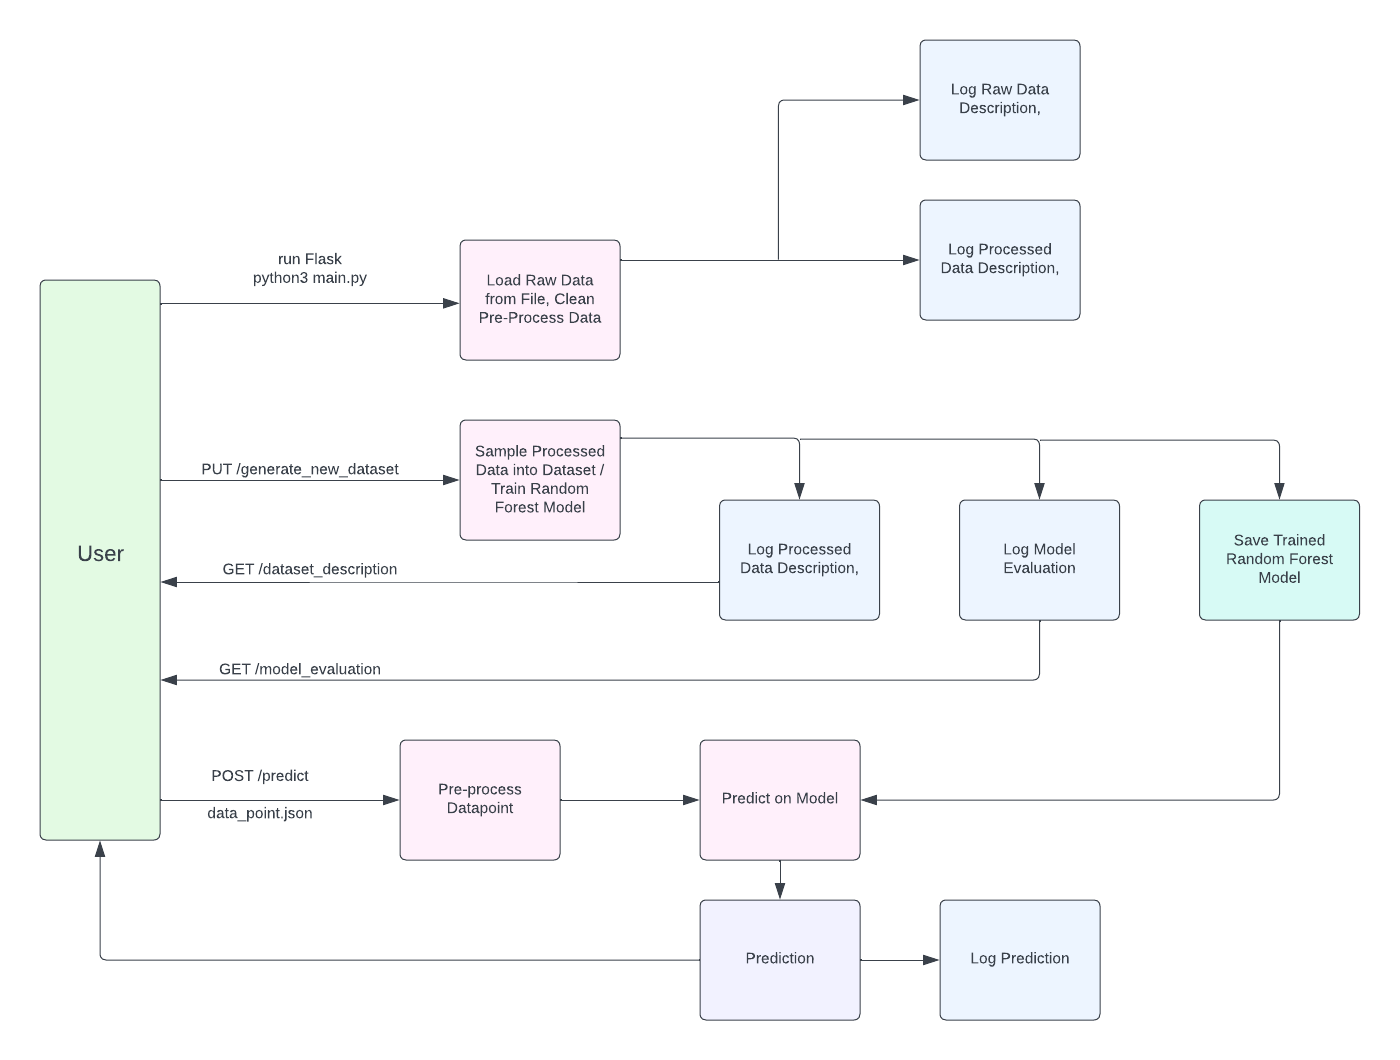

## 2. Data, Data Pipelines, and Model

### Description of the Data
The dataset consists of transaction data with fields such as transaction date and time, credit card number, merchant details, transaction amount, cardholder information (name, gender, address, job, date of birth), transaction number, geographic information (latitude and longitude), and a fraud indicator. The dataset is pre-processed to impute missing values, remove duplicated transactions, resolve inconsistencies. 

### Data Pipelines
The data pipelines involve several steps to process raw transaction data into a format suitable for model training and prediction:

1. **Data Extraction**:The data is extracted from three data files: 'transactions_0.csv', 'transactions_1.parquet', 'transactions_2.json'. The data from the three files are compiled into a single Datafram as the raw data. 

2. **Data Cleaning**: The data is cleaned to remove redundat transaction, handles missing values by imputing the mean or mode of a column, and resolves inconsistencies, such as transactions dated in the future.

3. **Feature Engineering**: New feautres are created to optimize the display of information in the data. The feature `age_group` is generated by calculaing the age of the customer based on the date of birth, and binning the age into age groups. The `day_of_week` and `hour_of_day` are extracted from the the transaciton date and time. The feature `distance` is the haversine distance between the customer's location and the merchant's location, provided by a latitude and longitude measurement. 

4. **Data Transformation**: The dates in the dataset are transformed, the categorical variables are one-hot encoded and the numerical feautures are scaled from 0 to 1.

5. **Data Sampling**: As the data is severely unbalanced, data sampling helps level the class distribution before model training. When the API call is prompted to generate a new dataset, with a given dataset version name, a sample of the processed dataset is taken from the processed data. The majority class (non-fraudulent/legitimate transactions) is undersampled to 10x more than the number of fraudulent transactions. This is then followed by a random oversampling of the minority class (fraudulent transactions) to get an even distribution of classes.

### Model
Once a new dataset is generated, the dataset is stratified split into a training set (80%) and test set (20%). The model used for fraud detection is a RandomForestClassifier from the scikit-learn library. The hyperparameter tuning in Module 4 showed that the default parameters performed the best for the data, hence the default hyperparameters are used. The model is trained on the processed dataset and evaluated using various metrics, such as precision, recall, accuracy, f1-score and ROC-AUC to ensure high accuracy and robustness.

## 3. Metrics

### Offline Metrics
A mixture of offline metrics are used to evaluate the trained Random Forest model. As the data is unbalanced due to the rare occasion of fraudulent charges, precision, recall and the ROC-AUC metrics provide greater insight into the model's ability to identify the rare fraudulent charges. 

- **Accuracy**: Measures the proportion of correctly classified transactions. In unbalanced datasets, accuracy can be misleading. For example, if 95% of transactions are non-fraudulent, a model that always predicts 'non-fraudulent' would achieve 95% accuracy, but would fail to identify any fraudulent transactions.

- **Precision**: Measures the proportion of true positives among the predicted positives. Precision focuses on the accuracy of the positive predictions (fraudulent transactions). In unbalanced datasets, this is crucial because it helps measure how many of the predicted frauds are actual frauds, reducing false positives.

- **Recall**: Measures the proportion of true positives among the actual positives. Recall measures how well the model identifies all actual fraud cases. High recall in unbalanced datasets ensures that the model is effective in catching most of the fraudulent transactions, even if it results in some false positives.

- **F1 Score**: The F1 score balances precision and recall, providing a single metric that considers both false positives and false negatives. This is particularly useful in unbalanced datasets to ensure a balance between identifying frauds and avoiding false alarms.

- **ROC-AUC**: The ROC-AUC metric evaluates the model's performance across all classification thresholds. It provides insight into the model's ability to distinguish between fraudulent and non-fraudulent transactions, which is essential for understanding its effectiveness in unbalanced datasets.

By focusing on these metrics, the system ensures that it effectively identifies fraudulent transactions while minimizing false positives and false negatives, which is critical for maintaining user trust and financial security.


### Online Metrics
While not implemented in the current system, the following are some online metrics that can faciliate the system requirements and help attain business goals.
- **Prediction Latency**: Measures the time taken to make a prediction.
- **Throughput**: Measures the number of transactions processed per second.
- **Error Rate**: Measures the proportion of erroneous predictions.


As real-time predictions are crucial for the fraud detection system, prediction latency is a metric that can be used to test the speed of the system. A lower latency allows for faster reaction and investigation on fraudulent charges. Throughput is another metric that measures the speed of the system, as well as the volume of transaction the system encounters. Keeping track of increasing and decreasing transaction volumes may help in dealing with scalbility issues and concerns. The error rate can be assessed as flagged transaction are reviewed and classified as a true positive or a false positive. The error rate can be calculated periodically to evaluate how the model works on unseen data. An increasing error rate can be an indication of data drift and may require re-training and re-evaluation of the model and the prediction pipeline. 

## 4. Analysis on System Parameters and Configurations

The abundance of logged information from the pipeline allows for seamless auditing of the system, checking for inconsistences, and pipeline errors.

### Data Quality Evaluation
The raw data is evaluated for quality by checking for missing values, duplicates, and inconsistencies. Before data transformations/imputation and feature engineering, the raw data is evaluated for structure and quality and logged into a file under `resources/logs/raw_data`. This includes, column names, column mean/median/minimum/maximum/standard deviation, size of data(set), missing values, unique values, data types, among other crucial information. Once evaluated, the following steps are taken:

- **Missing Values**: Imputed using the median for numerical columns and mode for categorical columns.
- **Duplicates**: Removed to ensure data integrity.
- **Inconsistencies**: Resolved by standardizing date formats and correcting anomalies. 

### Feature Engineering Evaluation
The features are evaluated to ensure they provide meaningful information for the model:

- **Age_Group**: Calculated from the date of birth and current date.
- **Day of Week**: Extracted from the transaction date.
- **Hour of Day**: Extracted from the transaction time.
- **Distance**: Calculated using the Haversine formula between cardholder and merchant locations.

The processed data is evaluated for structure and quality and logged into a file under `resources/logs/processed_data`. This includes, column names, column mean/median/minimum/maximum/standard deviation, size of data(set), missing values, unique values, data types, among other crucial information. This ensures that the data has been processed correctly and meaningfully. 

### Dataset Evaluation

When the API call is prompted to generate a new dataset, with a given dataset version name, a sample of the processed dataset is taken from the processed data. The samples processed data is evaluated for structure and quality and logged into a file under `resources/logs/dataset_descriptions`. This includes, column names, column mean/median/minimum/maximum/standard deviation, size of data(set), missing values, unique values, data types, among other crucial information. This allows one to evaluate the information on which a model is trained. Evaluating the dataset allows inspection for potential biasa and misrepresented information. 

### Model Evaluation

Each dataset generated is split into a 80/20 train/test split. The training set is used to train a Random Forest classifier model, and is then evaluated on the test set. The model is evaluated using the offline metrics described above, and logged to a file under `resources/logs/evaluation`. A different model evaluation is found for each Random Forest classifier trained on each of the individual generated datsets. The model evaluations give insight into the performance of the model on the test set before deployed into prediction of real-time inference transactions. This gives insight into how the model performs on unseen data and sets a benchmark for how well the model may run. Increasing deviation from this standard may require a re-evaluation of the pipeline, model and the data used. 

## 5. Post-Deployment Policies

### Monitoring and Maintenance Plan
- **Continuous Monitoring**: The system's performance can be continuously monitored using online and offline metrics. The performance of the system on unseen, real-time data gives us insight into how the system fulfills business goals. The goal of the system is to positively mark fraudulent transactions for review, while keeping false positives and false negatives to the minimum. Evaluating the recall and precision of the model can help identify if the model continues to efficiently work. Monitoring also can log when performance may be low due to data drift, prompting a re-evaluation of the models, data and system performance. 

- **Regular Updates**: The model is retrained regularly with new data to ensure it remains accurate and effective, and up to mark on latest fraudulent trends and patterns.

- **Alerts and Notifications**: Alerts are set up to notify the team of any anomalies or issues in the system. This allows for effective review of the flagged transaction, leading to quick resolved tickets. 

### Fault Mitigation Strategies
- **Redundancy**: Redundant systems can be put in place to ensure continuous operation, in case of failure.
- **Error Handling**: Comprehensive error handling is implemented to manage exceptions and recover gracefully.
- **Backup and Recovery**: Regular backups are taken to ensure data integrity and quick recovery in case of data loss. Trained models are logged and stored and can be retrieved as neccesary. 
